#**Taskts to Perform in Shoe_Sales_Dataset**
Load the dataset using pandas and inspect basic structure (head(), shape, columns).

Check data types and convert columns (e.g., date to datetime, category to object).

Identify missing values and handle them (drop or impute).

Detect and remove duplicate records.
Generate summary statistics using .describe() to understand distributions.
Analyze individual features (histograms for numerical, count plots for categorical).

Identify outliers using boxplots or IQR method.

Perform bivariate analysis (e.g., scatter plots, groupby comparisons).

Create correlation matrix to find relationships between variables.

Summarize key insights and patterns for business understanding.

In [1]:
#importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#loading dataset
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/shoes_sales_dataset.csv")


  Sale_ID        Date        Brand Shoe_Type  Color Country Sales_Channel  \
0      S1  2025-11-24         Nike     Boots   Blue      UK        Online   
1      S2  2025-03-13     Skechers     Boots   Grey     USA          Mall   
2      S3  2025-08-05         Nike   Running  White      UK          Mall   
3      S4  2025-11-05  New Balance    Casual  Green     UAE          Mall   
4      S5  2025-10-07       Adidas    Formal   Grey  France        Online   

   Price_USD  Units_Sold  Revenue_USD  
0     112.40           4       449.60  
1     239.16           4       956.64  
2     191.04           2       382.08  
3     161.70           1       161.70  
4      64.32          14       900.48  
RangeIndex(start=0, stop=1000, step=1)


In [2]:
print(df.head())
print(df.shape)
print(df.columns)
df.info()


  Sale_ID        Date        Brand Shoe_Type  Color Country Sales_Channel  \
0      S1  2025-11-24         Nike     Boots   Blue      UK        Online   
1      S2  2025-03-13     Skechers     Boots   Grey     USA          Mall   
2      S3  2025-08-05         Nike   Running  White      UK          Mall   
3      S4  2025-11-05  New Balance    Casual  Green     UAE          Mall   
4      S5  2025-10-07       Adidas    Formal   Grey  France        Online   

   Price_USD  Units_Sold  Revenue_USD  
0     112.40           4       449.60  
1     239.16           4       956.64  
2     191.04           2       382.08  
3     161.70           1       161.70  
4      64.32          14       900.48  
(1000, 10)
Index(['Sale_ID', 'Date', 'Brand', 'Shoe_Type', 'Color', 'Country',
       'Sales_Channel', 'Price_USD', 'Units_Sold', 'Revenue_USD'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non

#**Insights**
Dataset contains 1000 rows and 10 columns

Dataset includes:

- Product details
- Sales information
- Revenue data
- Country and sales channel information

In [12]:
#We change the datatype of date from object to Datetime
#df['Date'].astype('datetime64[ns]') can also be used
df['Date']=pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sale_ID        1000 non-null   object        
 1   Date           1000 non-null   datetime64[ns]
 2   Brand          1000 non-null   object        
 3   Shoe_Type      1000 non-null   object        
 4   Color          1000 non-null   object        
 5   Country        1000 non-null   object        
 6   Sales_Channel  1000 non-null   object        
 7   Price_USD      1000 non-null   float64       
 8   Units_Sold     1000 non-null   int64         
 9   Revenue_USD    1000 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 78.3+ KB


In [3]:
#Checking for null values
df.isnull().sum()

,0
Sale_ID,0
Date,0
Brand,0
Shoe_Type,0
Color,0
Country,0
Sales_Channel,0
Price_USD,0
Units_Sold,0
Revenue_USD,0


#**Insights**
- No missing values found in dataset
- Dataset is clean and complete
- Since there are no missing values, no imputation or dropping is required.

In [4]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates if present
df = df.drop_duplicates()
# No duplicates found

Duplicate rows: 0


In [17]:
#Summary Statistics
df.describe()

,Date,Price_USD,Units_Sold,Revenue_USD
count,1000,1000.000000,1000.000000,1000.00000
mean,2025-07-01 12:28:48,137.856420,10.584000,1453.18603
min,2025-01-03 00:00:00,31.020000,1.000000,32.38000
25%,2025-04-03 18:00:00,81.915000,6.000000,561.05000
50%,2025-06-28 12:00:00,139.295000,10.000000,1132.62500
75%,2025-10-03 00:00:00,193.752500,16.000000,2163.35000
max,2025-12-31 00:00:00,249.940000,20.000000,4938.40000
std,NaN,64.270059,5.842181,1112.32648


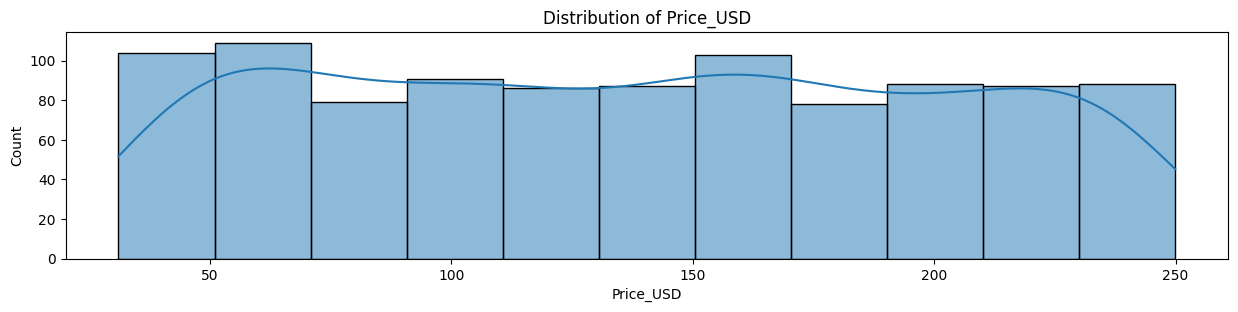

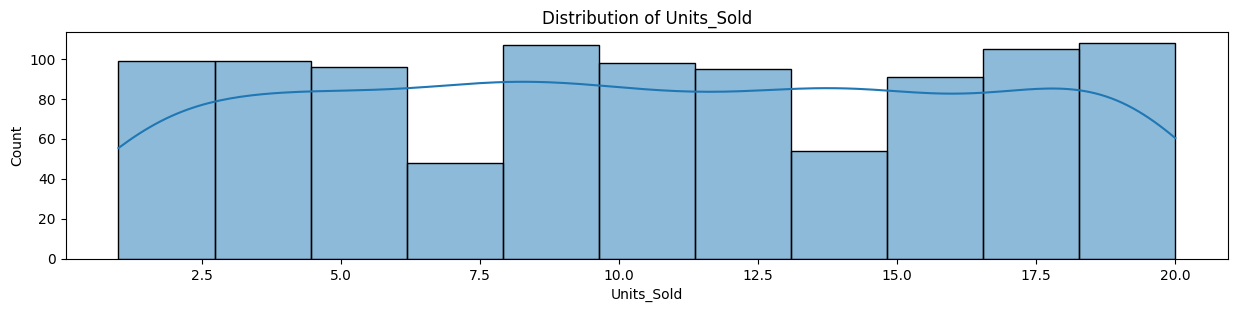

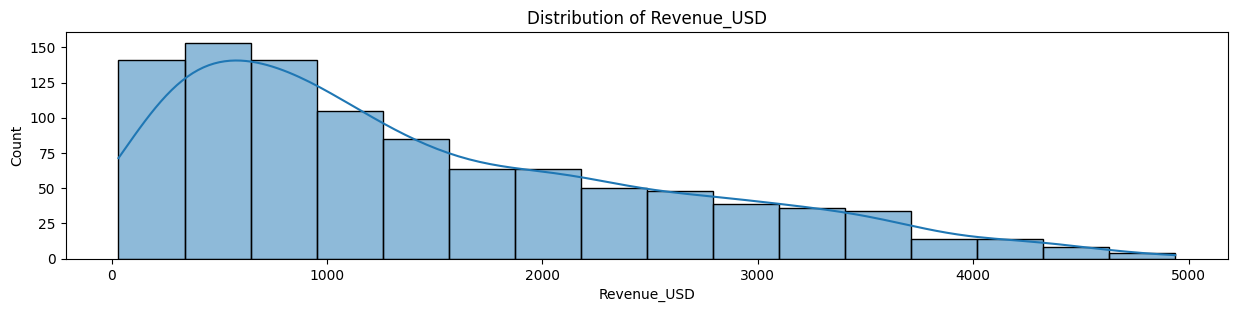

In [15]:
numerical = ["Price_USD", "Units_Sold", "Revenue_USD"]
for i,col in enumerate(numerical,1):
    plt.figure(figsize=(15, 10))
    plt.subplot(3,1,i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

#**Insights**
-  Shoe prices are distributed evenly in almost all the price ranges
- Units sold are distributed fairly evenly
- Revenue distribution is  right-skewed due to high sales values

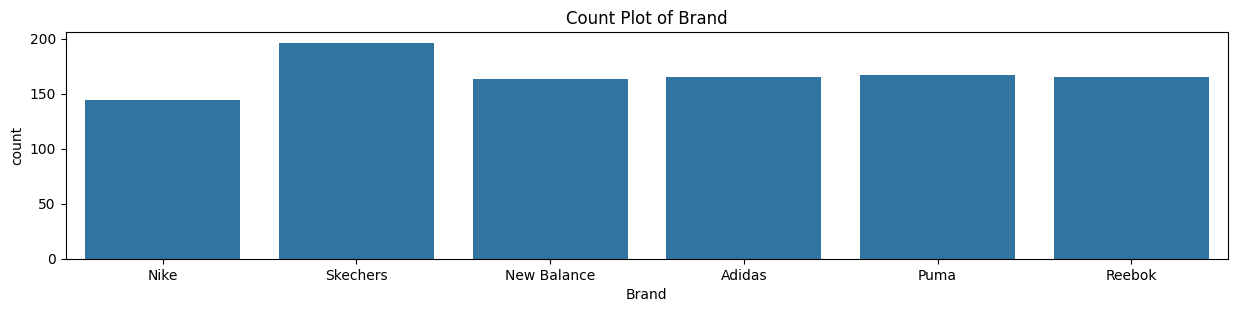

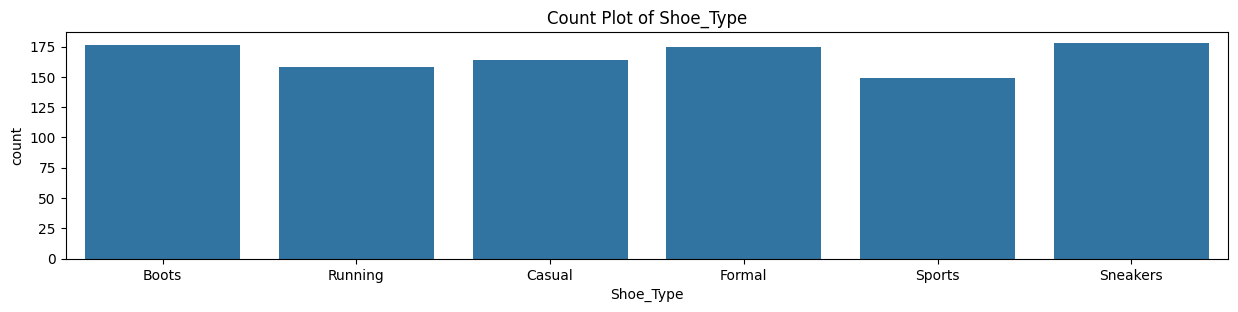

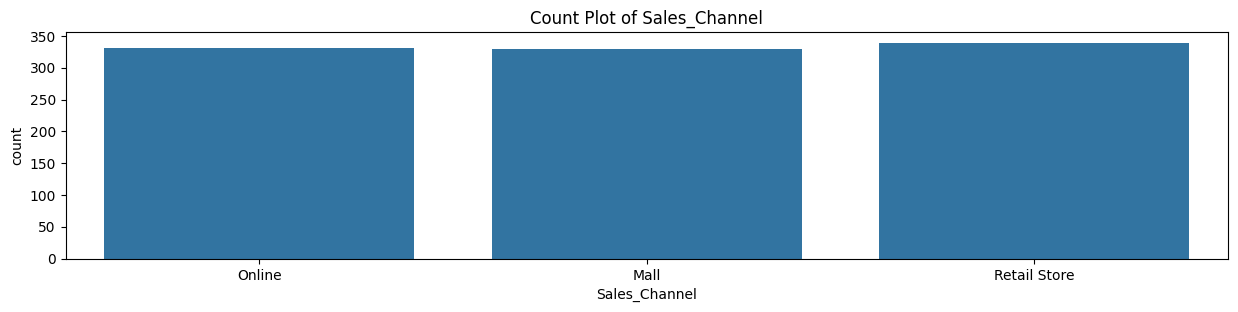

In [13]:
categorical = ["Brand", "Shoe_Type", "Sales_Channel"]
for i,col in enumerate(categorical,1):
    plt.figure(figsize=(15,10))
    plt.subplot(3,1,i)
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")

    plt.show()

#**Insights**
- Sketchers sales the most and Nike the least compare to others
- Sneakers and Boots are topping the charts may be this shows the trend going on.
- Sales are almost equal in all types and Retail stores keeping a slight edge



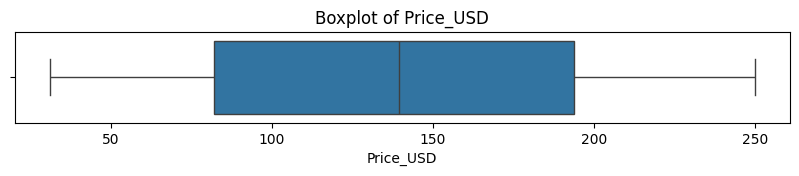

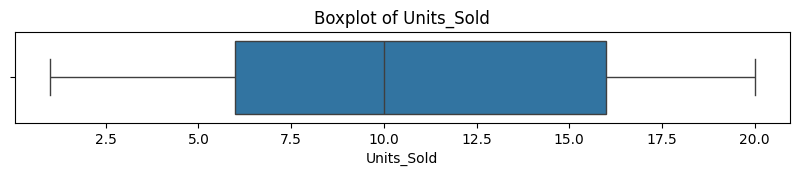

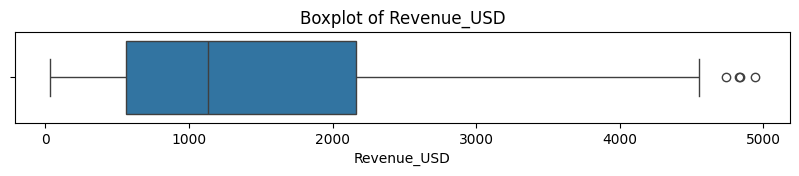

In [18]:
#Outlier Detection using Boxplots
for i,col in enumerate(numerical,1):
    plt.figure(figsize=(10,4))
    plt.subplot(3,1,i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

- Revenue column contains some high-value outliers
Units sold and Prices are moderate spread

In [20]:
# Detect outliers using IQR method
def outlier_detection(df,col):
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  return outliers

outliers = outlier_detection(df, 'Revenue_USD')
outliers.head()



,Sale_ID,Date,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD
140,S141,2025-11-07,New Balance,Casual,Grey,Germany,Retail Store,241.74,20,4834.80
446,S447,2025-01-31,Skechers,Boots,Grey,Germany,Mall,246.92,20,4938.40
843,S844,2025-11-11,Nike,Sneakers,Grey,Saudi Arabia,Online,241.44,20,4828.80
847,S848,2025-06-29,Skechers,Boots,Grey,USA,Retail Store,249.31,19,4736.89


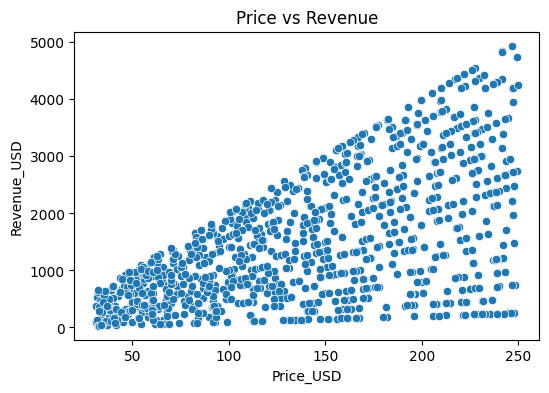

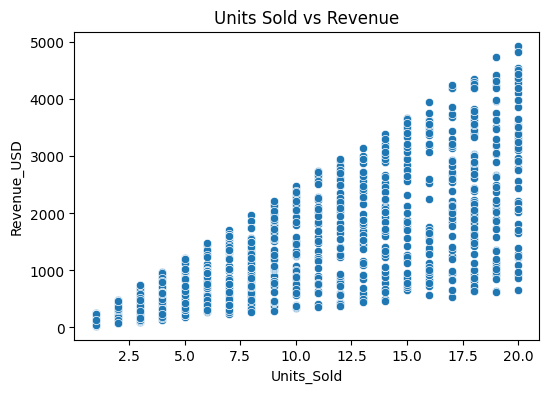

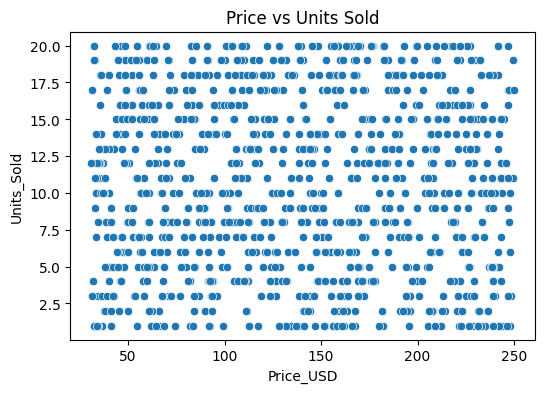

In [27]:
#Bivariate analysis using scatter plots
#Price_USD vs Revenue_USD
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df["Price_USD"],
    y=df["Revenue_USD"])
plt.title("Price vs Revenue")
plt.show()
#Units_sold vs Revenue_USD
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df["Units_Sold"],
    y=df["Revenue_USD"]
)
plt.title("Units Sold vs Revenue")
plt.show()

#Price_USD vs Units_Sold
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df["Price_USD"],
    y=df["Units_Sold"]
)
plt.title("Price vs Units Sold")
plt.show()

#**Insights**
- **Price_USD vs Revenue_USD** -

- Higher priced shoes may generate higher revenue
- Some low-priced products still achieve strong revenue through volume sales



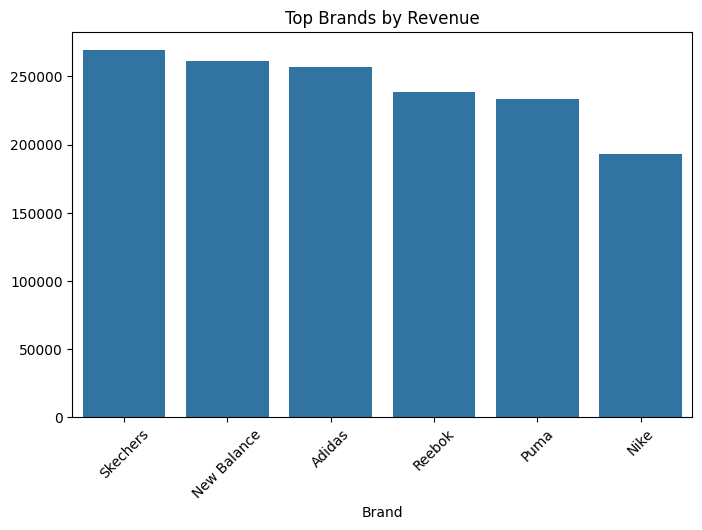

In [28]:
#Top Brands by Revenue
top_brands = df.groupby("Brand")["Revenue_USD"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(
    x=top_brands.index,
    y=top_brands.values
)
plt.title("Top Brands by Revenue")
plt.xticks(rotation=45)
plt.show()

#Insights
As we saw earlier Skechers has the highest revenue and nike the lowest

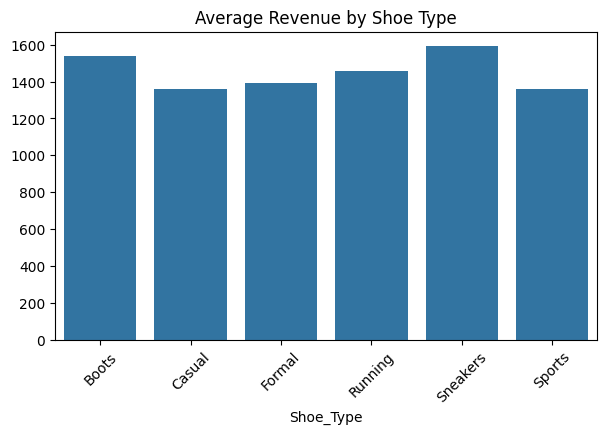

In [31]:
#Shoe ytpe and its revenue
shoe_revenue = df.groupby("Shoe_Type")["Revenue_USD"].mean()
plt.figure(figsize=(7,4))
sns.barplot(
    x=shoe_revenue.index,
    y=shoe_revenue.values
)
plt.title("Average Revenue by Shoe Type")
plt.xticks(rotation=45)
plt.show()

#Insights
Sneaker and Boots sales are highest may show a trend in style

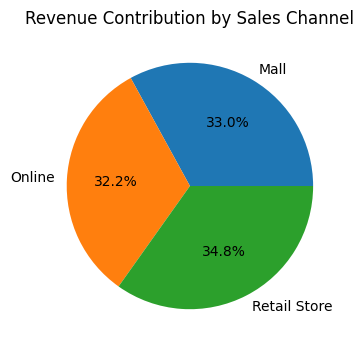

In [32]:
#Sales channel Grouping
channel_sales = df.groupby("Sales_Channel")["Revenue_USD"].sum()
plt.figure(figsize=(6,4))
plt.pie(
    channel_sales.values,
    labels=channel_sales.index,
    autopct='%1.1f%%'
)
plt.title("Revenue Contribution by Sales Channel")
plt.show()

#Insights
Retail Store sales Contribute the highest revenue by small margins then Onlime and Mall sales


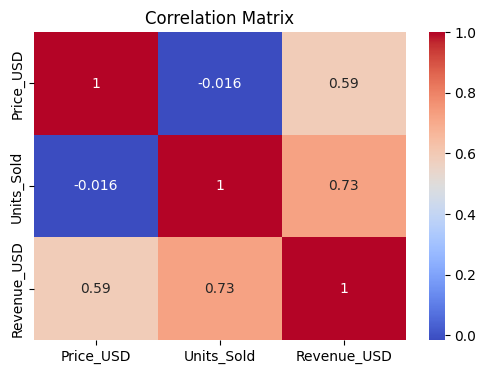

In [23]:
#Correlation matrix
plt.figure(figsize=(6,4))
corr = df[["Price_USD", "Units_Sold", "Revenue_USD"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

#**1. Strong Positive Correlation Between Revenue and Units Sold**

- Revenue increases significantly when more units are sold.

- Increasing product demand and sales volume can directly improve company revenue.
- Marketing campaigns and discounts may help increase unit sales.
#**2. Positive Correlation Between Price and Revenue**
- Higher priced shoes tend to generate higher revenue.
-Premium pricing strategies may help improve profitability.
High-value products can be an important revenue source.
#**3. Weak Correlation Between Price and Units Sold**
- Shoe price does not strongly affect units sold.
- Both expensive and affordable products are being purchased.

- Business can maintain multiple pricing categories successfully.
